# Capítulo 5

**Problema Motivador:**

Consider a database workstation server that is composed of:
- a single CPU 
- two disks, a fast disk and a slow disk. 

Users remotely login to the server, perform some database transactions, and logout. Because of the limited power of the workstation, at most two users are allowed to be logged onto the system at any one time. However, the demand for the system is sufficiently high so that it may be assumed that exactly two users are logged onto the system at all times. That is, as soon as one user completes the requested transactions and exits the system, another eager user logs on and effectively picks up where the departed user left off and initiates further database transactions. Each transaction alternates between using the CPU and using a disk. The particular disk used depends on the transaction, since different transactions access different files, and different files are resident on different disks. 

Suppose that the "typical" transaction 

- requires an average of 10 sec of CPU time,
- is equally likely to access files on the fast disk as the slow disk, 
- requires an average of 20 sec of fast disk time if a file on the fast disk is accessed, 
- requires an average of 30 sec of slow disk time if a file on the slow disk is accessed. 

What is the current performance of the system? How much would performance be improved if code for transaction handling by the CPU were rewritten to execute 33% faster? How much would performance be improved if the slow disk were replaced by a second fast disk? What is the optimal file placement across the two disks?

---
#### 5.3) What is the performance (utilizations, throughputs, queue lengths, and waittimes of each device) of the original system proposed by the motivating example in Sec. 5.3?

In [1]:
from line_solver import Network, Queue, ClosedClass, Exp, SolverMVA

model = Network("Database")

cpu = Queue(model, "CPU")
fast = Queue(model, "FastDisk")
slow = Queue(model, "SlowDisk")

jobs = ClosedClass(
    model,
    "Users",
    2,
    cpu,
    0
)

cpu.setService(jobs, Exp(60/10))
fast.setService(jobs, Exp(60/20))
slow.setService(jobs, Exp(60/30))

P = model.initRoutingMatrix()

P.set(jobs, jobs, cpu, fast, 0.5) 
P.set(jobs, jobs, cpu, slow, 0.5)
P.set(jobs, jobs, fast, cpu, 1.0)
P.set(jobs, jobs, slow, cpu, 1.0)

model.link(P)

model.link(P)

solver = SolverMVA(model)
print(solver.getAvgTable())

    Station JobClass     QLen     Util    RespT   ResidT    ArvR    Tput
0       CPU    Users  0.54545  0.42424  0.21429  0.21429  2.5455  2.5455
1  FastDisk    Users  0.54545  0.42424  0.42857  0.21429  1.2727  1.2727
2  SlowDisk    Users  0.90909  0.63636  0.71429  0.35714  1.2727  1.2727


<br>
<br>

---

#### 5.4) Referring to the motivating example in Sec. 5.3, by how much would performance be improved if code for transaction handling by the CPU were rewritten to execute 33% faster?

In [2]:
from line_solver import Network, Queue, ClosedClass, Exp, SolverMVA

model = Network("Database")

cpu = Queue(model, "CPU")
fast = Queue(model, "FastDisk")
slow = Queue(model, "SlowDisk")

jobs = ClosedClass(
    model,
    "Users",
    2,
    cpu,
    0
)

cpu.setService(jobs, Exp(60 / (10 * (1 - 1/3))))
fast.setService(jobs, Exp(60/20))
slow.setService(jobs, Exp(60/30))

P = model.initRoutingMatrix()

P.set(jobs, jobs, cpu, fast, 0.5) 
P.set(jobs, jobs, cpu, slow, 0.5)
P.set(jobs, jobs, fast, cpu, 1.0)
P.set(jobs, jobs, slow, cpu, 1.0)

model.link(P)


solver = SolverMVA(model)
print(solver.getAvgTable())

    Station JobClass     QLen     Util    RespT   ResidT    ArvR    Tput
0       CPU    Users  0.37247  0.30769   0.1345   0.1345  2.7692  2.7692
1  FastDisk    Users  0.60729  0.46154   0.4386   0.2193  1.3846  1.3846
2  SlowDisk    Users   1.0202  0.69231  0.73684  0.36842  1.3846  1.3846


<br>
<br>

---

#### 5.5) Referring to the motivating example in Sec. 5.3, by how much would performance be improved if the slow disk were replaced by a second fast disk?

In [3]:
from line_solver import Network, Queue, ClosedClass, Exp, SolverMVA

model = Network("Database")

cpu = Queue(model, "CPU")
fast = Queue(model, "FastDisk")
slow = Queue(model, "SlowDisk")

jobs = ClosedClass(
    model,
    "Users",
    2,
    cpu,
    0
)

cpu.setService(jobs, Exp(60/10))
fast.setService(jobs, Exp(60/20))
slow.setService(jobs, Exp(60/20))

P = model.initRoutingMatrix()

P.set(jobs, jobs, cpu, fast, 0.5) 
P.set(jobs, jobs, cpu, slow, 0.5)
P.set(jobs, jobs, fast, cpu, 1.0)
P.set(jobs, jobs, slow, cpu, 1.0)

model.link(P)

model.link(P)

solver = SolverMVA(model)
print(solver.getAvgTable())

    Station JobClass     QLen Util    RespT   ResidT ArvR Tput
0       CPU    Users  0.66667  0.5  0.22222  0.22222    3    3
1  FastDisk    Users  0.66667  0.5  0.44444  0.22222  1.5  1.5
2  SlowDisk    Users  0.66667  0.5  0.44444  0.22222  1.5  1.5


<br>
<br>

---

#### 5.6) Referring to the motivating example in Sec. 5.3, by how much is CPU throughput improved if 10% of the files are moved from the slow disk to the fast disk? What about 50%? (This implies changing the value of p.)

In [ ]:
from line_solver import Network, Queue, ClosedClass, Exp, SolverMVA

def make_model(p_fast):
    model = Network("Database")
    cpu = Queue(model, "CPU")
    fast = Queue(model, "FastDisk")
    slow = Queue(model, "SlowDisk")
    jobs = ClosedClass(model, "Users", 2, cpu, 0)
    
    cpu.setService(jobs, Exp(60/10))
    fast.setService(jobs, Exp(60/20))
    slow.setService(jobs, Exp(60/30))

    P = model.initRoutingMatrix()
    P.set(jobs, jobs, cpu, fast, p_fast)
    P.set(jobs, jobs, cpu, slow, 1.0 - p_fast)
    P.set(jobs, jobs, fast, cpu, 1.0)
    P.set(jobs, jobs, slow, cpu, 1.0)
    model.link(P)
    return model


print(SolverMVA(make_model(0.5)).getAvgTable()[['Station', 'Tput']])
solver = SolverMVA(make_model(0.6))
print("Movendo 10% dos arquivos do slow disk para o fast disk")
print(solver.getAvgTable())
print("\n\n")

solver = SolverMVA(make_model(1.0))
print("Movendo 50% dos arquivos do slow disk para o fast disk")
print(solver.getAvgTable())

    Station     Tput
0       CPU  2.54545
1  FastDisk  1.27273
2  SlowDisk  1.27273
Movendo 10% dos arquivos do slow disk para o fast disk
    Station JobClass     QLen     Util    RespT   ResidT    ArvR    Tput
0       CPU    Users  0.56995  0.44041  0.21569  0.21569  2.6425  2.6425
1  FastDisk    Users  0.71503   0.5285  0.45098  0.27059  1.5855  1.5855
2  SlowDisk    Users  0.71503   0.5285  0.67647  0.27059   1.057   1.057



Movendo 50% dos arquivos do slow disk para o fast disk
    Station JobClass     QLen     Util    RespT   ResidT    ArvR    Tput
0       CPU    Users  0.57143  0.42857  0.22222  0.22222  2.5714  2.5714
1  FastDisk    Users   1.4286  0.85714  0.55556  0.55556  2.5714  2.5714


<br>
<br>

---

#### 5.7) Referring to the motivating example in Sec. 5.3, what is the optimal file placement across the two disks? (This implies varying the value of p, observing the effect upon performance, and selecting the optimal value of p.)

Optimal p = 0.77 (throughput = 2.7142 trans/min)


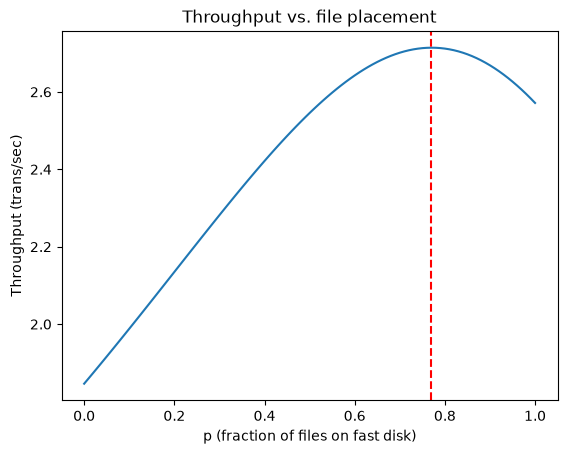

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from line_solver import Network, Queue, ClosedClass, Exp, SolverMVA

p_values = np.linspace(0.0, 1.0, 101)
throughputs = []

for p in p_values:
    model = Network("Database")
    cpu = Queue(model, "CPU")
    fast = Queue(model, "FastDisk")
    slow = Queue(model, "SlowDisk")
    jobs = ClosedClass(model, "Users", 2, cpu, 0)

    cpu.setService(jobs, Exp(60/10))
    fast.setService(jobs, Exp(60/20))
    slow.setService(jobs, Exp(60/30))

    P = model.initRoutingMatrix()
    P.set(jobs, jobs, cpu, fast, p)
    P.set(jobs, jobs, cpu, slow, 1.0 - p)
    P.set(jobs, jobs, fast, cpu, 1.0)
    P.set(jobs, jobs, slow, cpu, 1.0)
    model.link(P)

    table = SolverMVA(model).getAvgTable()
    tput = float(table['Tput'].max())
    throughputs.append(tput)

optimal_p = p_values[np.argmax(throughputs)]
print(f"Optimal p = {optimal_p:.2f} (throughput = {max(throughputs):.4f} trans/min)")

plt.plot(p_values, throughputs)
plt.axvline(optimal_p, color='r', linestyle='--', label=f'optimal p={optimal_p:.2f}')
plt.xlabel("p (fraction of files on fast disk)")
plt.ylabel("Throughput (trans/sec)")
plt.title("Throughput vs. file placement")
plt.show()

<br>
<br>

---

#### 5.8) Referring to the motivating example in Sec. 5.3, by how much is CPU throughput improved by increasing the MPL from 2 to 3?

In [6]:
from line_solver import Network, Queue, ClosedClass, Exp, SolverMVA

model = Network("Database")

cpu = Queue(model, "CPU")
fast = Queue(model, "FastDisk")
slow = Queue(model, "SlowDisk")

jobs = ClosedClass(
    model,
    "Users",
    3,
    cpu,
    0
)

cpu.setService(jobs, Exp(60/10))
fast.setService(jobs, Exp(60/20))
slow.setService(jobs, Exp(60/30))

P = model.initRoutingMatrix()

P.set(jobs, jobs, cpu, fast, 0.5) 
P.set(jobs, jobs, cpu, slow, 0.5)
P.set(jobs, jobs, fast, cpu, 1.0)
P.set(jobs, jobs, slow, cpu, 1.0)

model.link(P)

solver = SolverMVA(model)
print(solver.getAvgTable())

    Station JobClass     QLen     Util    RespT   ResidT    ArvR    Tput
0       CPU    Users  0.77863  0.50382  0.25758  0.25758  3.0229  3.0229
1  FastDisk    Users  0.77863  0.50382  0.51515  0.25758  1.5115  1.5115
2  SlowDisk    Users   1.4427  0.75573  0.95455  0.47727  1.5115  1.5115


<br>
<br>

---

#### 5.15) A computer system has one CPU and two disks, disk 1 and disk 2. The system was monitored for 1 hour and the utilization of the CPU and of disk 1 were measured to be 32%32% and 60%60%, respectively. Each transaction makes 5 I/O requests to disk 1 and 8 to disk 2. The average service time at disk 1 is 30 msec and at disk 2 is 25 msec.

(a) Find the system throughput.

(b) Find the utilization of disk 2.

(c) Find the average service demands at the CPU, disk 1, and disk 2.

(d) Use MVA to find the system throughput, response time, and average queue length at the CPU and the disks when the degree of multiprogramming is $n$, for $n=0,\ldots,4$.

(e) Based on your results for item (d), what would be a good approximation for the average degree of multiprogramming during the measurement interval?

In [7]:
from line_solver import Network, Queue, ClosedClass, Exp, SolverMVA

U_cpu = 0.32 # utilização medida da CPU
U_disk1 = 0.60 # utilização medida do disco 1
V_disk1 = 5 # visitas por transação ao disco 1
V_disk2 = 8 # visitas por transação ao disco 2
S_disk1 = 0.030 # tempo de serviço disco 1 (seg)
S_disk2 = 0.025 # tempo de serviço disco 2 (seg)

print("-"*20)
print("Item a)")
D_disk1 = V_disk1 * S_disk1
X = U_disk1 / D_disk1
print(f"(a) Throughput X = {X:.4f} trans/seg")

print("-"*20)
print("Item b)")
D_disk2 = V_disk2 * S_disk2
U_disk2 = X * D_disk2
print(f"(b) Utilização Disk2 = {U_disk2:.4f} ({U_disk2*100:.1f}%)")

print("-"*20)
print("Item c)")
D_cpu = U_cpu / X
print(f"(c) Demandas de serviço:")
print(f" CPU = {D_cpu * 1000:.3f} msec")
print(f" Disk1 = {D_disk1 * 1000:.3f} msec")
print(f" Disk2 = {D_disk2 * 1000:.3f} msec")


print("-"*20)
print("Item d)")

for n in range(1, 5):
    model = Network("System")
    cpu   = Queue(model, "CPU")
    disk1 = Queue(model, "Disk1")
    disk2 = Queue(model, "Disk2")
    jobs  = ClosedClass(model, "Trans", n, cpu, 0)

    cpu.setService(jobs,   Exp(60/D_cpu))
    disk1.setService(jobs, Exp(60/D_disk1))
    disk2.setService(jobs, Exp(60/D_disk2))

    P = model.initRoutingMatrix()
    P.set(jobs, jobs, cpu,   disk1, 1.0)
    P.set(jobs, jobs, disk1, disk2, 1.0)
    P.set(jobs, jobs, disk2, cpu,   1.0)
    model.link(P)

    print(f"\n--- n={n} ---")
    print(SolverMVA(model).getAvgTable())

--------------------
Item a)
(a) Throughput X = 4.0000 trans/seg
--------------------
Item b)
(b) Utilização Disk2 = 0.8000 (80.0%)
--------------------
Item c)
(c) Demandas de serviço:
 CPU = 80.000 msec
 Disk1 = 150.000 msec
 Disk2 = 200.000 msec
--------------------
Item d)

--- n=1 ---
  Station JobClass     QLen     Util      RespT     ResidT    ArvR    Tput
0     CPU    Trans  0.18605  0.18605  0.0013333  0.0013333  139.53  139.53
1   Disk1    Trans  0.34884  0.34884     0.0025     0.0025  139.53  139.53
2   Disk2    Trans  0.46512  0.46512  0.0033333  0.0033333  139.53  139.53

--- n=2 ---
  Station JobClass     QLen     Util      RespT     ResidT    ArvR    Tput
0     CPU    Trans  0.32151  0.27108  0.0015814  0.0015814  203.31  203.31
1   Disk1    Trans  0.68558  0.50827  0.0033721  0.0033721  203.31  203.31
2   Disk2    Trans  0.99291   0.6777  0.0048837  0.0048837  203.31  203.31

--- n=3 ---
  Station JobClass    QLen     Util      RespT     ResidT    ArvR    Tput
0     CPU

<br>
<br>

---

#### 5.16) Consider the CPU/fast disk/slow disk example, with $\mu c=6$, $\mu f=3$, $\mu s=2$, $p=0.5$, and $MPL=2$. Solve this system using the decomposition/aggregation technique and compare the answers by solving the same system using convolution.


In [ ]:
import numpy as np
from line_solver import Network, Queue, ClosedClass, Exp, SolverMVA

mu_c = 6
mu_f = 3
mu_s = 2
p = 0.5
MPL = 2

print(
    f"Parâmetros: mu_c={mu_c}, mu_f={mu_f}, "
    f"mu_s={mu_s}, p={p}, MPL={MPL}\n"
)

def io_subsystem(muf, mus, p, N):
    m = Network("IO")

    f = Queue(m, "Fast")
    s = Queue(m, "Slow")

    job = ClosedClass(m, "c", N, f, 0)

    f.setService(job, Exp(muf))
    s.setService(job, Exp(mus))

    P = m.initRoutingMatrix()

    P.set(job, job, f, f, p)
    P.set(job, job, f, s, 1 - p)
    P.set(job, job, s, f, p)
    P.set(job, job, s, s, 1 - p)

    m.link(P)

    return m


mu_io = {}

for n in [1, 2]:
    t = SolverMVA(
        io_subsystem(mu_f, mu_s, p, n)
    ).getAvgTable()

    mu_io[n] = float(t["Tput"].sum())

print("=" * 55)
print("Decomposição/Agregação (FESC)")
print("=" * 55)
print(
    f"taxas do FESC: "
    f"mu_io(1)={mu_io[1]:.4f} "
    f"mu_io(2)={mu_io[2]:.4f}"
)

pi = np.zeros(MPL + 1)

pi[0] = 1.0
pi[1] = pi[0] * mu_c / mu_io[1]
pi[2] = pi[1] * mu_c / mu_io[2]

pi /= pi.sum()

print(f"probabilidades: {np.round(pi, 5)}")

X_cpu = mu_c * (pi[0] + pi[1])
U_cpu = 1 - pi[MPL]

n_cpu = 2 * pi[0] + 1 * pi[1]
n_fesc = 1 * pi[1] + 2 * pi[2]

print(
    f"\nDecomposição -> CPU: "
    f"X={X_cpu:.4f} "
    f"U={U_cpu:.4f} "
    f"n_cpu={n_cpu:.4f}"
)

print(f"                 FESC: n_fesc={n_fesc:.4f}")


print("\n" + "=" * 55)
print("Convolução / MVA exato (3 estações)")
print("=" * 55)

m2 = Network("Conv")

cpu2 = Queue(m2, "CPU")
df = Queue(m2, "FastDisk")
ds = Queue(m2, "SlowDisk")

cls2 = ClosedClass(m2, "Jobs", MPL, cpu2, 0)

cpu2.setService(cls2, Exp(mu_c))
df.setService(cls2, Exp(mu_f))
ds.setService(cls2, Exp(mu_s))

P2 = m2.initRoutingMatrix()

P2.set(cls2, cls2, cpu2, df, p)
P2.set(cls2, cls2, cpu2, ds, 1 - p)

P2.set(cls2, cls2, df, cpu2, 1.0)
P2.set(cls2, cls2, ds, cpu2, 1.0)

m2.link(P2)

t2 = SolverMVA(m2).getAvgTable()

print(t2)

X_exact = float(t2["Tput"].max())
n_disks = float(t2["QLen"][1]) + float(t2["QLen"][2])

print(
    f"\nExato -> CPU: "
    f"X={X_exact:.4f} "
    f"U={float(t2['Util'][0]):.4f} "
    f"n_cpu={float(t2['QLen'][0]):.4f}"
)

print(f"          Discos: n_fesc={n_disks:.4f}")

Parâmetros: mu_c=6, mu_f=3, mu_s=2, p=0.5, MPL=2

Decomposição/Agregação (FESC)
taxas do FESC: mu_io(1)=2.4000 mu_io(2)=3.1579
probabilidades: [0.12121 0.30303 0.57576]

Decomposição -> CPU: X=2.5455 U=0.4242 n_cpu=0.5455
                 FESC: n_fesc=1.4545

Convolução / MVA exato (3 estações)
    Station JobClass     QLen     Util    RespT   ResidT    ArvR    Tput
0       CPU     Jobs  0.54545  0.42424  0.21429  0.21429  2.5455  2.5455
1  FastDisk     Jobs  0.54545  0.42424  0.42857  0.21429  1.2727  1.2727
2  SlowDisk     Jobs  0.90909  0.63636  0.71429  0.35714  1.2727  1.2727

Exato -> CPU: X=2.5455 U=0.4242 n_cpu=0.5455
          Discos: n_fesc=1.4545


# Referências

Here are the relevant official documentation links:

- Python Manual (PDF): https://line-solver.sourceforge.net/doc/LINE-python.pdf
- Python API Reference (Sphinx): https://line-solver.sourceforge.net/sphinx/index.html
- Cheatsheet (PDF): https://line-solver.sourceforge.net/doc/LINE-cheatsheet.pdf
- GitHub repo: https://github.com/imperial-qore/line-solver